# SomaTrack — Phase 4: Model Analysis & Evaluation
**Input:** Pre-computed results from GPU training run  
(`baseline_results.json`, `tuning_scores.json`, `best_model_names.json`)

---
## Table of Contents
1. [Setup & Load Results](#1)
2. [Baseline Model Comparison](#2)
3. [Tuning Improvement Analysis](#3)
4. [Best Model Selection Summary](#4)
5. [Per-Target Performance Deep-Dive](#5)
6. [Cross-Model Ranking Analysis](#6)
7. [Final Summary Table & Export](#7)


## 1. Setup & Load Results

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json, warnings
warnings.filterwarnings('ignore')

# ── Style ─────────────────────────────────────────────────────────────────────
TARGET_COLORS = {
    'target_back_pain':'#e74c3c',  'target_neck_strain':'#e67e22',
    'target_headache':'#f39c12',   'target_wrist_pain':'#2ecc71',
    'target_eye_strain':'#3498db', 'target_finger_numb':'#9b59b6',
    'target_overall':'#1abc9c',
}
TARGET_NICE = {
    'target_back_pain':'Back Pain',       'target_neck_strain':'Neck Strain',
    'target_headache':'Headache',         'target_wrist_pain':'Wrist Pain',
    'target_eye_strain':'Eye Strain',     'target_finger_numb':'Finger Numb.',
    'target_overall':'Overall Discomfort',
}
MODEL_COLORS = {'LR':'#3498db','RF':'#27ae60','XGB':'#e67e22','LGBM':'#9b59b6','DUMMY':'#bdc3c7'}
CLASS_NAMES  = ['None','Mild','Moderate','Chronic']

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.grid.axis': 'y',
    'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 11, 'axes.labelsize': 10,
})

# ── Load results ──────────────────────────────────────────────────────────────
with open('baseline_results.json')  as f: baseline  = json.load(f)
with open('tuning_scores.json')     as f: tuning    = json.load(f)
with open('best_model_names.json')  as f: best_names = json.load(f)
with open('fs_metadata.json')       as f: meta       = json.load(f)

TARGET_COLS  = meta['target_cols']
FEATURE_COLS = meta['selected_features']
MODEL_NAMES  = ['LR','RF','XGB','LGBM']

print("Results loaded successfully.")
print(f"Targets  : {len(TARGET_COLS)}")
print(f"Models   : {MODEL_NAMES}")
print(f"\nBest model per target:")
for t, m in best_names.items():
    best_tuned = max(tuning[t], key=tuning[t].get)
    print(f"  {TARGET_NICE[t]:22s}  baseline_best={m}   "
          f"tuned_best={best_tuned}  "
          f"tuned_F1={tuning[t][best_tuned]:.4f}")


Results loaded successfully.
Targets  : 7
Models   : ['LR', 'RF', 'XGB', 'LGBM']

Best model per target:
  Back Pain               baseline_best=XGB   tuned_best=XGB  tuned_F1=0.3838
  Neck Strain             baseline_best=RF   tuned_best=RF  tuned_F1=0.3648
  Headache                baseline_best=XGB   tuned_best=XGB  tuned_F1=0.3338
  Wrist Pain              baseline_best=RF   tuned_best=RF  tuned_F1=0.4109
  Eye Strain              baseline_best=RF   tuned_best=RF  tuned_F1=0.3446
  Finger Numb.            baseline_best=LGBM   tuned_best=LGBM  tuned_F1=0.3891
  Overall Discomfort      baseline_best=RF   tuned_best=RF  tuned_F1=0.6838


## 2. Baseline Model Comparison

In [3]:
# ── Pivot table: F1_weighted per model × target ───────────────────────────────
rows = []
for t in TARGET_COLS:
    for m in MODEL_NAMES + ['DUMMY']:
        r = baseline[t][m]
        rows.append({
            'Target':      TARGET_NICE[t],
            'Model':       m,
            'F1_Weighted': round(r['f1_weighted'], 4),
            'F1_Macro':    round(r['f1_macro'],    4),
            'Accuracy':    round(r['accuracy'],    4),
            'F1_wt_std':   round(r['f1_wt_std'],   4),
        })
baseline_df = pd.DataFrame(rows)

print("=== BASELINE CV RESULTS (F1-Weighted) ===")
pivot = baseline_df[baseline_df['Model'] != 'DUMMY'].pivot(
    index='Model', columns='Target', values='F1_Weighted')
print(pivot.round(4).to_string())
print()
print("DUMMY baseline:")
for t in TARGET_COLS:
    print(f"  {TARGET_NICE[t]:22s}: {baseline[t]['DUMMY']['f1_weighted']:.4f}")


=== BASELINE CV RESULTS (F1-Weighted) ===
Target  Back Pain  Eye Strain  Finger Numb.  Headache  Neck Strain  Overall Discomfort  Wrist Pain
Model                                                                                             
LGBM       0.3646      0.3172        0.3735    0.3130       0.3258              0.6515      0.3721
LR         0.3495      0.2997        0.3199    0.3104       0.3043              0.4861      0.3690
RF         0.3647      0.3276        0.3835    0.3188       0.3403              0.6761      0.3949
XGB        0.3752      0.3106        0.3738    0.3123       0.3291              0.6541      0.3782

DUMMY baseline:
  Back Pain             : 0.1667
  Neck Strain           : 0.1607
  Headache              : 0.1667
  Wrist Pain            : 0.2096
  Eye Strain            : 0.1644
  Finger Numb.          : 0.2007
  Overall Discomfort    : 0.4221


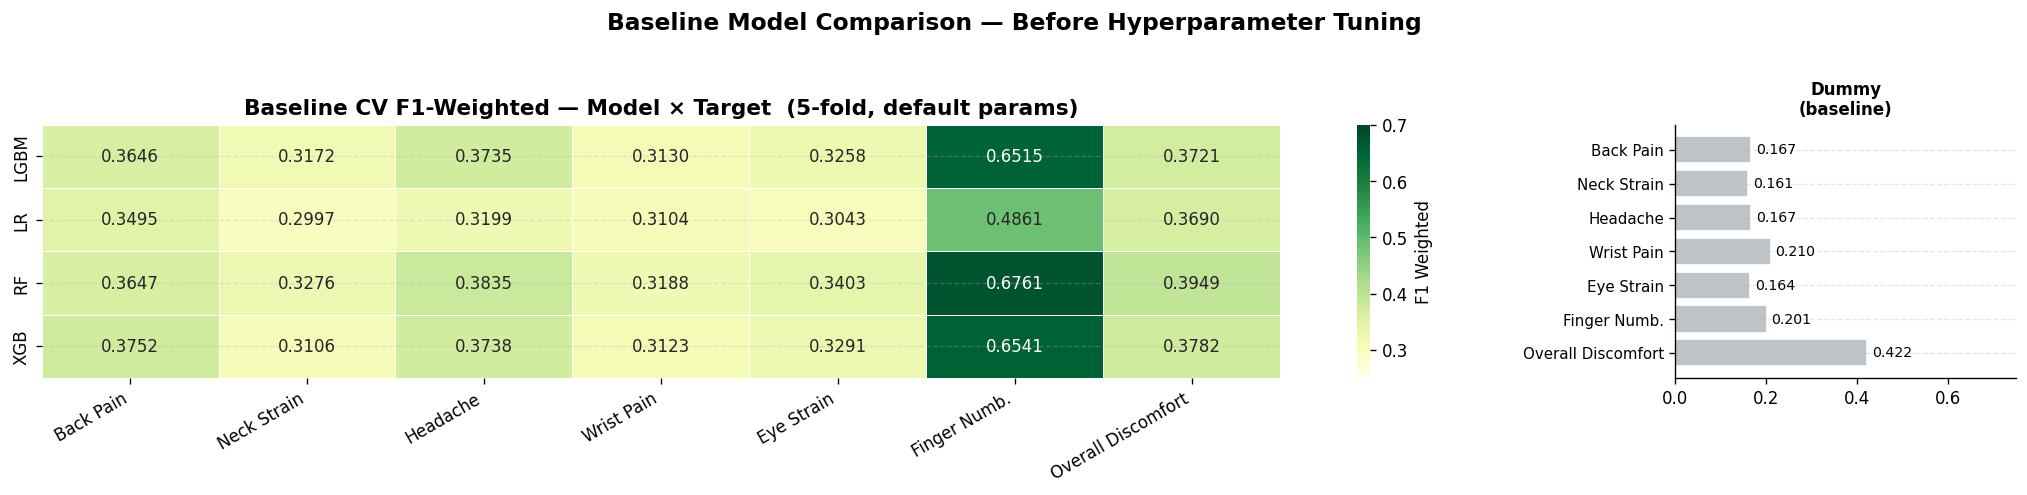

In [4]:
# ── Heatmap: baseline F1-weighted ────────────────────────────────────────────
pivot_main = baseline_df[baseline_df['Model'] != 'DUMMY'].pivot(
    index='Model', columns='Target', values='F1_Weighted')
pivot_main.columns = [TARGET_NICE[t] for t in TARGET_COLS]
dummy_vals = [baseline[t]['DUMMY']['f1_weighted'] for t in TARGET_COLS]

fig, axes = plt.subplots(1, 2, figsize=(17, 4),
                          gridspec_kw={'width_ratios': [5, 1.1]})

sns.heatmap(pivot_main, annot=True, fmt='.4f', cmap='YlGn',
            vmin=0.25, vmax=0.70, linewidths=0.5,
            ax=axes[0], annot_kws={'size': 10},
            cbar_kws={'label': 'F1 Weighted'})
axes[0].set_title('Baseline CV F1-Weighted — Model × Target  (5-fold, default params)',
                   fontweight='bold', fontsize=13)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].set_ylabel('')

axes[1].barh(range(len(TARGET_COLS)), dummy_vals[::-1],
             color='#bdc3c7', edgecolor='white')
axes[1].set_yticks(range(len(TARGET_COLS)))
axes[1].set_yticklabels([TARGET_NICE[t] for t in TARGET_COLS[::-1]], fontsize=9)
axes[1].set_title('Dummy\n(baseline)', fontweight='bold', fontsize=10)
axes[1].set_xlim(0, 0.75)
for j, v in enumerate(dummy_vals[::-1]):
    axes[1].text(v + 0.01, j, '{:.3f}'.format(v), va='center', fontsize=8.5)

plt.suptitle('Baseline Model Comparison — Before Hyperparameter Tuning',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


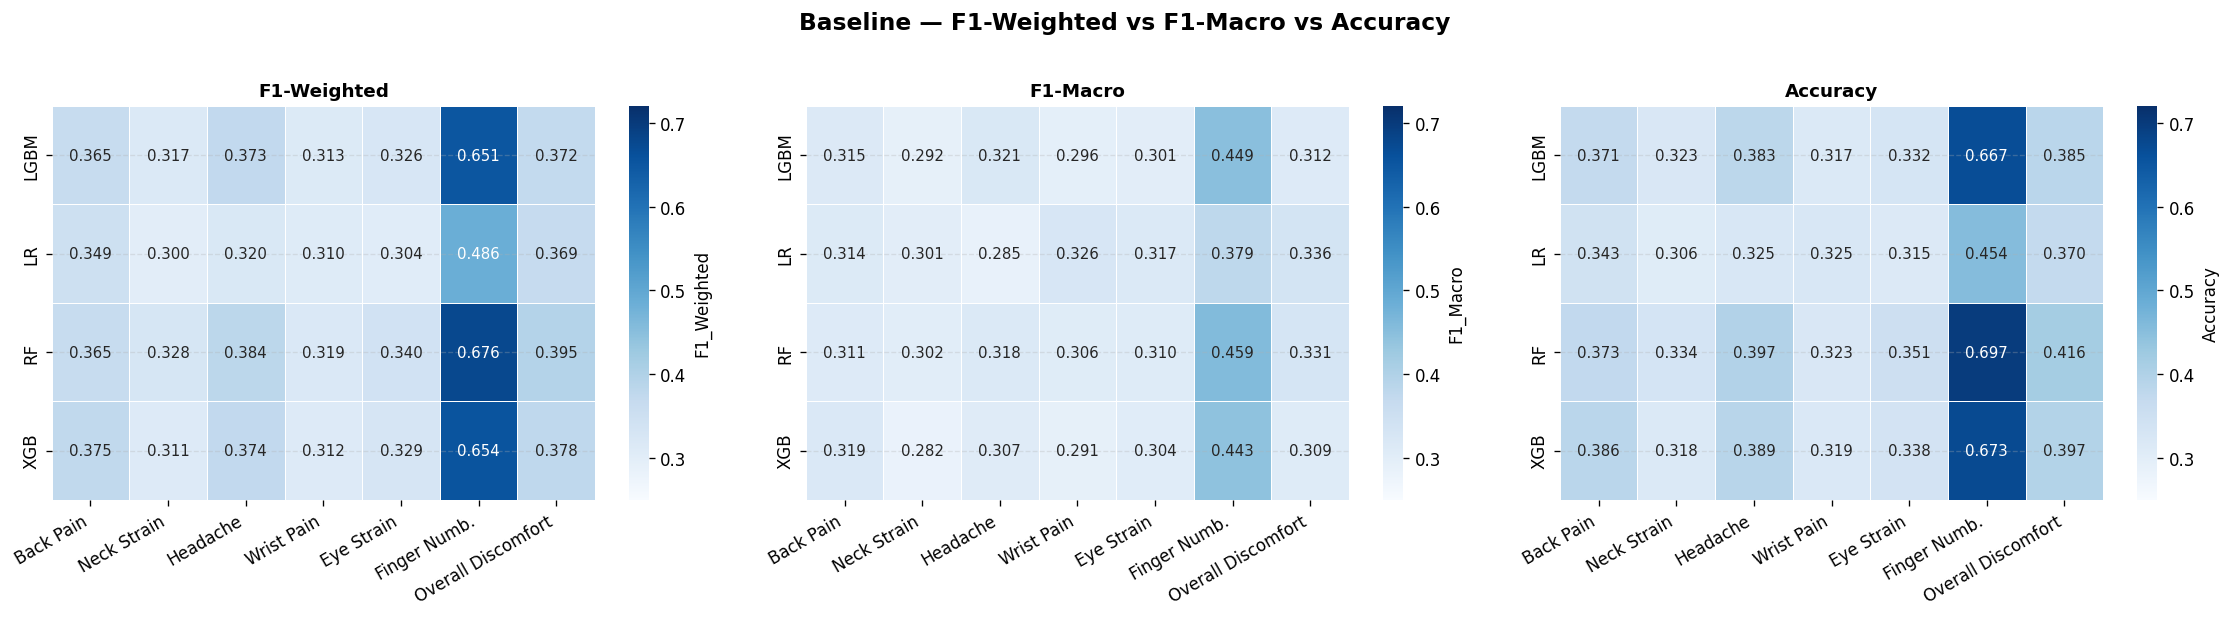

In [5]:
# ── Per-metric comparison: F1_weighted vs F1_macro vs Accuracy ───────────────
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
metrics    = ['F1_Weighted','F1_Macro','Accuracy']
metric_titles = ['F1-Weighted','F1-Macro','Accuracy']

for ax, metric, title in zip(axes, metrics, metric_titles):
    piv = baseline_df[baseline_df['Model'] != 'DUMMY'].pivot(
        index='Model', columns='Target', values=metric)
    piv.columns = [TARGET_NICE[t] for t in TARGET_COLS]
    sns.heatmap(piv, annot=True, fmt='.3f', cmap='Blues',
                vmin=0.25, vmax=0.72, linewidths=0.4,
                ax=ax, annot_kws={'size': 9},
                cbar_kws={'label': metric})
    ax.set_title(f'{title}', fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.set_ylabel('')

plt.suptitle('Baseline — F1-Weighted vs F1-Macro vs Accuracy',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


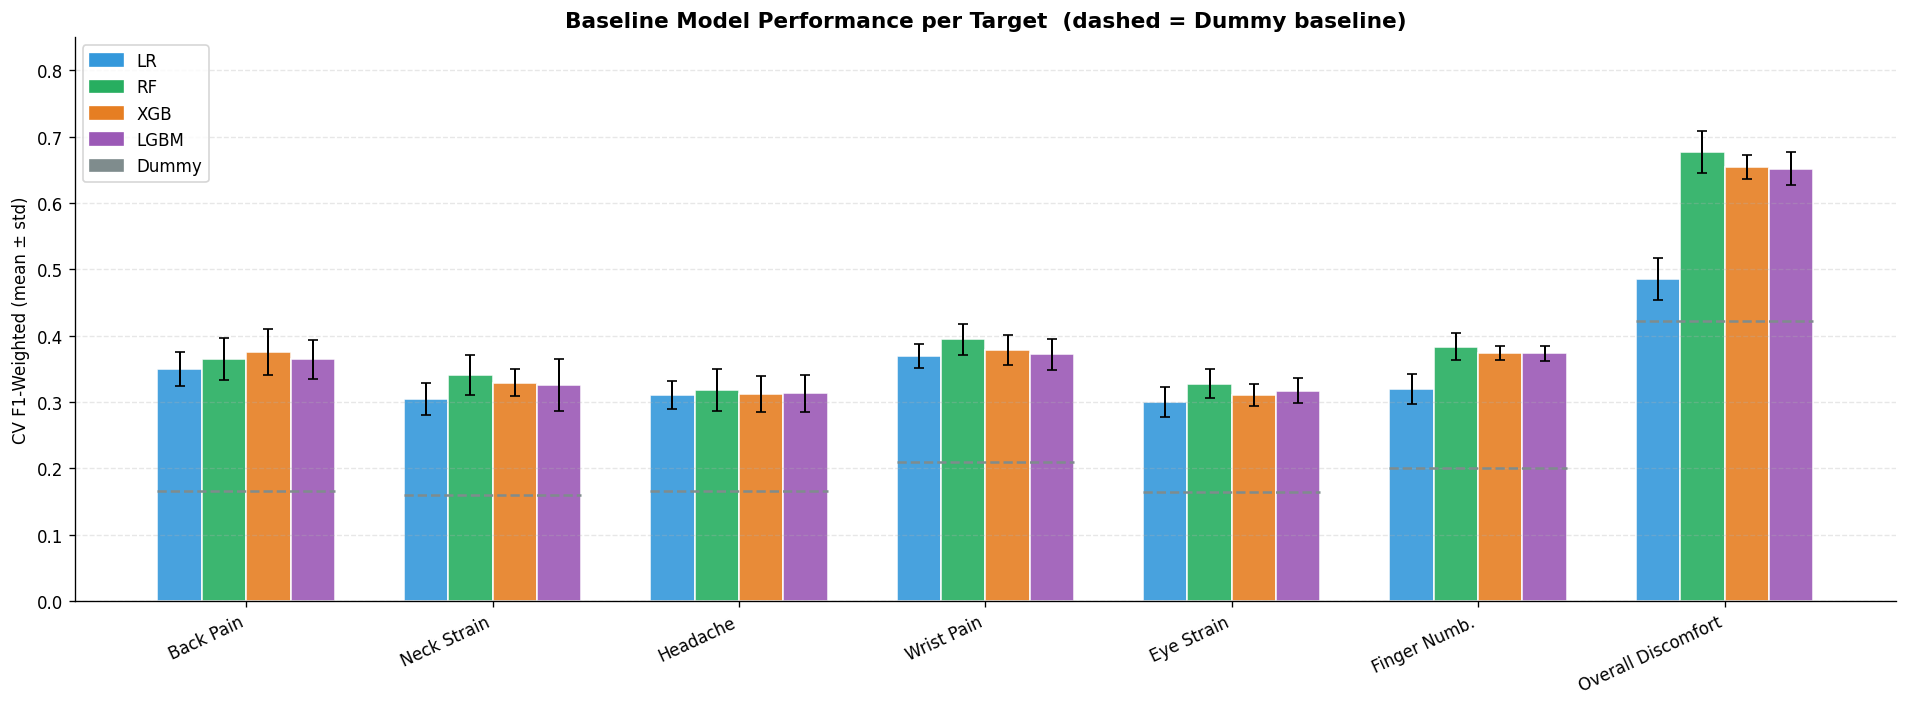

In [6]:
# ── Grouped bar: all 4 models across all targets ─────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
x  = np.arange(len(TARGET_COLS))
w  = 0.18

for j, m in enumerate(MODEL_NAMES):
    vals = [baseline[t][m]['f1_weighted'] for t in TARGET_COLS]
    errs = [baseline[t][m]['f1_wt_std']   for t in TARGET_COLS]
    offset = (j - 1.5) * w
    ax.bar(x + offset, vals, width=w,
           color=MODEL_COLORS[m], edgecolor='white',
           label=m, alpha=0.9, yerr=errs, capsize=3,
           error_kw={'lw': 1.2})

# Dummy reference line per target
for i, t in enumerate(TARGET_COLS):
    ax.hlines(baseline[t]['DUMMY']['f1_weighted'],
              i - 2*w, i + 2*w,
              colors='#7f8c8d', lw=1.5, linestyles='--')

ax.set_xticks(x)
ax.set_xticklabels([TARGET_NICE[t] for t in TARGET_COLS], rotation=25, ha='right')
ax.set_ylabel('CV F1-Weighted (mean ± std)')
ax.set_ylim(0, 0.85)
ax.set_title('Baseline Model Performance per Target  (dashed = Dummy baseline)',
             fontweight='bold', fontsize=13)
legend_els = [mpatches.Patch(color=MODEL_COLORS[m], label=m) for m in MODEL_NAMES]
legend_els.append(mpatches.Patch(color='#7f8c8d', label='Dummy'))
ax.legend(handles=legend_els, fontsize=10, loc='upper left')
plt.tight_layout()
plt.show()


## 3. Tuning Improvement Analysis

In [7]:
# Build tuning improvement table
tuning_rows = []
for t in TARGET_COLS:
    for m, tuned_f1 in tuning[t].items():
        base_f1 = baseline[t][m]['f1_weighted']
        gain    = tuned_f1 - base_f1
        tuning_rows.append({
            'Target':     TARGET_NICE[t],
            'Model':      m,
            'Baseline':   round(base_f1,  4),
            'Tuned':      round(tuned_f1, 4),
            'Gain':       round(gain,     4),
            'Gain_%':     round(gain / base_f1 * 100, 2),
        })

tuning_df = pd.DataFrame(tuning_rows).sort_values(['Target','Tuned'], ascending=[True, False])
print("=== TUNING IMPROVEMENT (Baseline → Tuned CV F1-Weighted) ===")
print(tuning_df.to_string(index=False))


=== TUNING IMPROVEMENT (Baseline → Tuned CV F1-Weighted) ===
            Target Model  Baseline  Tuned   Gain  Gain_%
         Back Pain   XGB    0.3752 0.3838 0.0086    2.28
         Back Pain    RF    0.3647 0.3837 0.0190    5.20
         Back Pain  LGBM    0.3646 0.3799 0.0154    4.21
        Eye Strain    RF    0.3276 0.3446 0.0169    5.17
        Eye Strain   XGB    0.3106 0.3386 0.0280    9.03
        Eye Strain  LGBM    0.3172 0.3354 0.0182    5.73
      Finger Numb.  LGBM    0.3735 0.3891 0.0156    4.18
      Finger Numb.    RF    0.3835 0.3859 0.0024    0.63
      Finger Numb.   XGB    0.3738 0.3804 0.0066    1.77
          Headache   XGB    0.3123 0.3338 0.0215    6.88
          Headache  LGBM    0.3130 0.3318 0.0188    6.00
          Headache    RF    0.3188 0.3247 0.0059    1.85
       Neck Strain    RF    0.3403 0.3648 0.0245    7.19
       Neck Strain   XGB    0.3291 0.3563 0.0272    8.26
       Neck Strain  LGBM    0.3258 0.3453 0.0195    5.99
Overall Discomfort    RF   

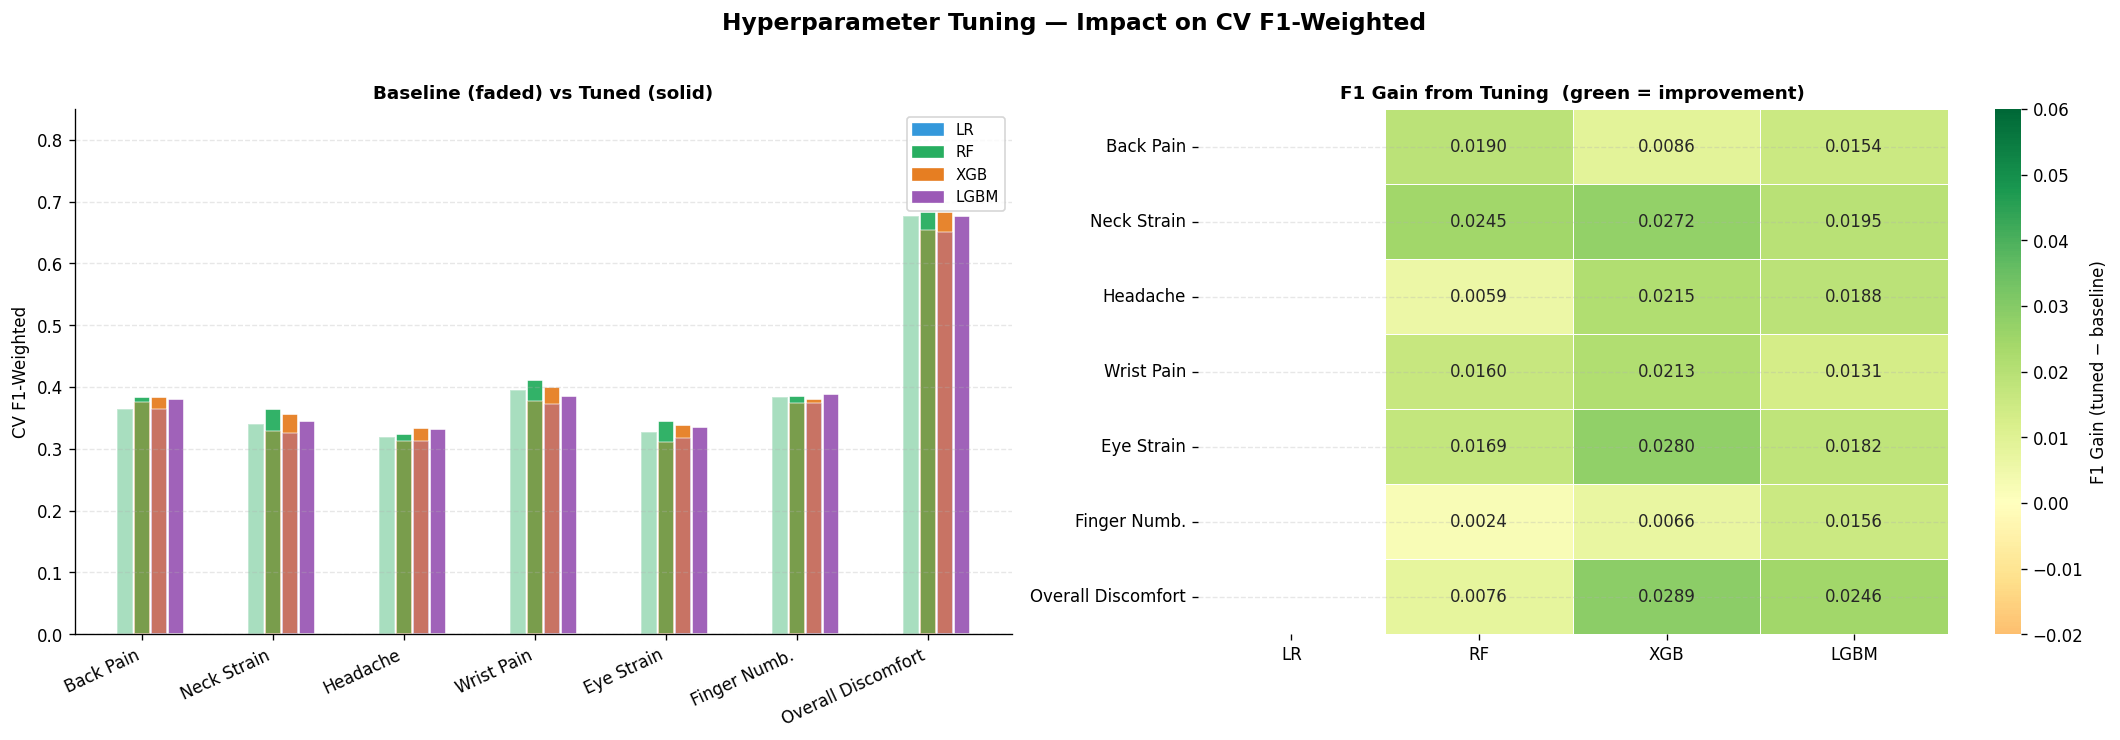

In [8]:
# ── Baseline vs tuned — before/after bars ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: absolute scores
x  = np.arange(len(TARGET_COLS))
w  = 0.13

for j, m in enumerate(MODEL_NAMES):
    base_vals  = [baseline[t][m]['f1_weighted']
                  for t in TARGET_COLS if m in tuning[t]]
    tuned_vals = [tuning[t][m]
                  for t in TARGET_COLS if m in tuning[t]]
    t_subset   = [t for t in TARGET_COLS if m in tuning[t]]
    x_sub      = np.array([list(TARGET_COLS).index(t) for t in t_subset])
    offset     = (j - 1.5) * w

    axes[0].bar(x_sub + offset - w/2, base_vals,  width=w*0.9,
                color=MODEL_COLORS[m], alpha=0.40, edgecolor='white')
    axes[0].bar(x_sub + offset + w/2, tuned_vals, width=w*0.9,
                color=MODEL_COLORS[m], alpha=0.95, edgecolor='white')

axes[0].set_xticks(x)
axes[0].set_xticklabels([TARGET_NICE[t] for t in TARGET_COLS], rotation=25, ha='right')
axes[0].set_ylabel('CV F1-Weighted')
axes[0].set_ylim(0, 0.85)
axes[0].set_title('Baseline (faded) vs Tuned (solid)', fontweight='bold')
legend_els = [mpatches.Patch(color=MODEL_COLORS[m], label=m) for m in MODEL_NAMES]
axes[0].legend(handles=legend_els, fontsize=9)

# Right: gain heatmap
gain_data = {}
for t in TARGET_COLS:
    gain_data[TARGET_NICE[t]] = {}
    for m in MODEL_NAMES:
        if m in tuning[t]:
            gain_data[TARGET_NICE[t]][m] = round(
                tuning[t][m] - baseline[t][m]['f1_weighted'], 4)
        else:
            gain_data[TARGET_NICE[t]][m] = np.nan

gain_df = pd.DataFrame(gain_data).T
sns.heatmap(gain_df, annot=True, fmt='.4f', cmap='RdYlGn',
            center=0, vmin=-0.02, vmax=0.06,
            linewidths=0.5, ax=axes[1],
            annot_kws={'size': 10},
            cbar_kws={'label': 'F1 Gain (tuned − baseline)'},
            mask=gain_df.isnull())
axes[1].set_title('F1 Gain from Tuning  (green = improvement)',
                   fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

plt.suptitle('Hyperparameter Tuning — Impact on CV F1-Weighted',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 4. Best Model Selection Summary

In [9]:
# Determine best tuned model per target
best_tuned = {t: max(tuning[t], key=tuning[t].get) for t in TARGET_COLS}

print("=== BEST MODEL PER TARGET ===")
print(f"{'Target':22s}  {'Best Model':10s}  {'Tuned F1_wt':11s}  "
      f"{'vs Baseline':11s}  {'vs 2nd Best':11s}")
print("-" * 72)

for t in TARGET_COLS:
    best_m  = best_tuned[t]
    best_f1 = tuning[t][best_m]
    base_f1 = baseline[t][best_m]['f1_weighted']
    gain    = best_f1 - base_f1

    sorted_tuning = sorted(tuning[t].items(), key=lambda x: x[1], reverse=True)
    second_f1 = sorted_tuning[1][1] if len(sorted_tuning) > 1 else best_f1
    margin    = best_f1 - second_f1

    print(f"  {TARGET_NICE[t]:22s}  {best_m:10s}  {best_f1:.4f}       "
          f"+{gain:.4f}       +{margin:.4f}")


=== BEST MODEL PER TARGET ===
Target                  Best Model  Tuned F1_wt  vs Baseline  vs 2nd Best
------------------------------------------------------------------------
  Back Pain               XGB         0.3838       +0.0086       +0.0001
  Neck Strain             RF          0.3648       +0.0245       +0.0085
  Headache                XGB         0.3338       +0.0215       +0.0020
  Wrist Pain              RF          0.4109       +0.0160       +0.0114
  Eye Strain              RF          0.3446       +0.0169       +0.0060
  Finger Numb.            LGBM        0.3891       +0.0156       +0.0032
  Overall Discomfort      RF          0.6838       +0.0076       +0.0007


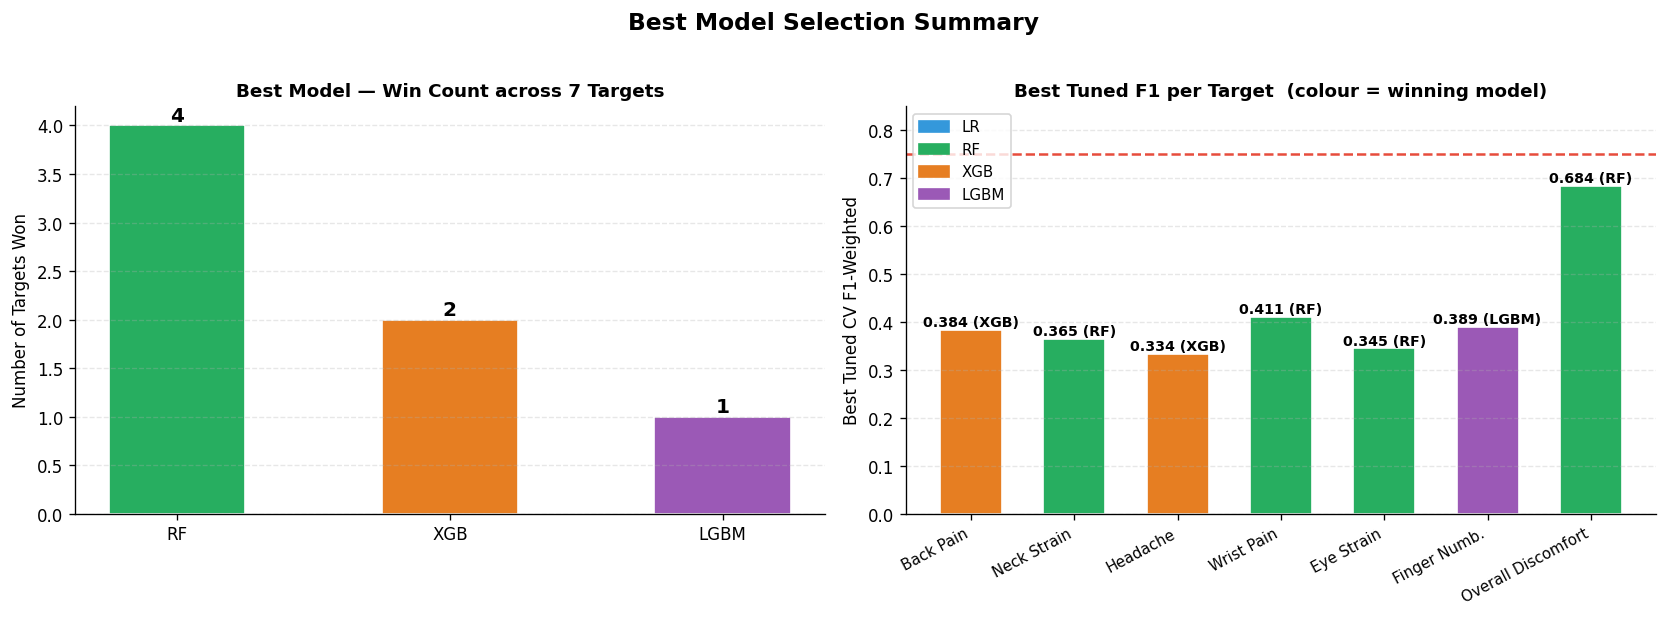

In [10]:
# ── Best model frequency & score comparison ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: which model wins most targets
from collections import Counter
win_counts = Counter(best_tuned.values())
models_sorted = sorted(win_counts.keys(), key=lambda m: win_counts[m], reverse=True)
colors_wins   = [MODEL_COLORS[m] for m in models_sorted]
bars = axes[0].bar(models_sorted, [win_counts[m] for m in models_sorted],
                   color=colors_wins, edgecolor='white', width=0.5)
axes[0].set_ylabel('Number of Targets Won')
axes[0].set_title('Best Model — Win Count across 7 Targets', fontweight='bold')
for bar, m in zip(bars, models_sorted):
    v = win_counts[m]
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.05, str(v),
                 ha='center', fontsize=12, fontweight='bold')

# Right: tuned F1 per target coloured by winning model
targets_nice = [TARGET_NICE[t] for t in TARGET_COLS]
best_f1s     = [tuning[t][best_tuned[t]] for t in TARGET_COLS]
bar_colors   = [MODEL_COLORS[best_tuned[t]] for t in TARGET_COLS]

bars2 = axes[1].bar(range(len(TARGET_COLS)), best_f1s,
                    color=bar_colors, edgecolor='white', width=0.6)
axes[1].axhline(0.75, color='#e74c3c', lw=1.5, linestyle='--',
                label='F1 = 0.75 target')
axes[1].set_xticks(range(len(TARGET_COLS)))
axes[1].set_xticklabels(targets_nice, rotation=28, ha='right', fontsize=9)
axes[1].set_ylabel('Best Tuned CV F1-Weighted')
axes[1].set_ylim(0, 0.85)
axes[1].set_title('Best Tuned F1 per Target  (colour = winning model)',
                   fontweight='bold')
for bar, v, t in zip(bars2, best_f1s, TARGET_COLS):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.008,
                 "{:.3f} ({})".format(v, best_tuned[t]),
                 ha='center', fontsize=8.5, fontweight='bold')
legend_els = [mpatches.Patch(color=MODEL_COLORS[m], label=m) for m in MODEL_NAMES]
axes[1].legend(handles=legend_els, fontsize=9, loc='upper left')

plt.suptitle('Best Model Selection Summary', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 5. Per-Target Performance Deep-Dive

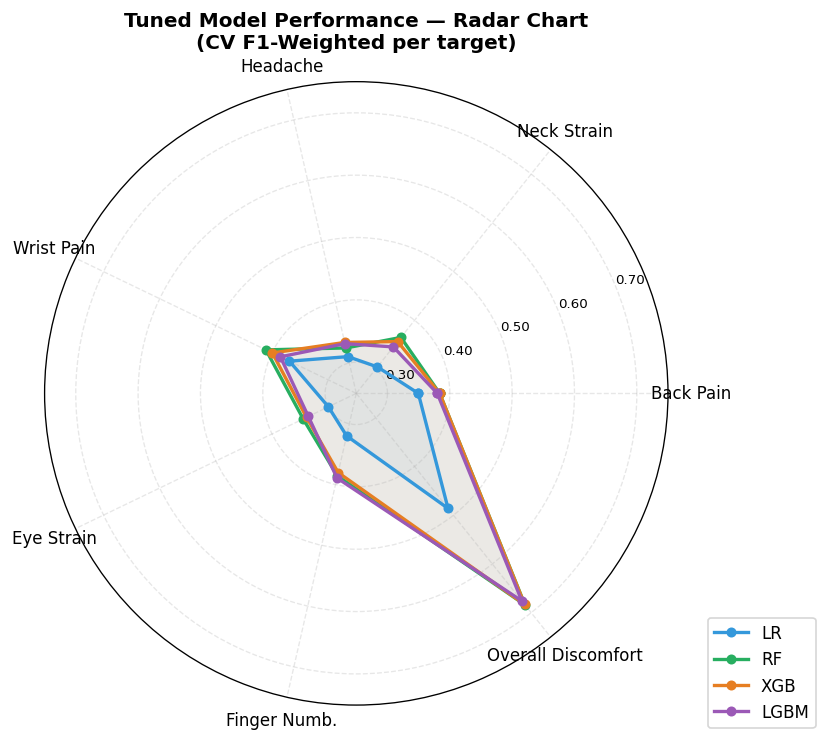

In [11]:
# ── Radar chart: tuned F1 across all targets ─────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

angles = np.linspace(0, 2*np.pi, len(TARGET_COLS), endpoint=False).tolist()
angles += angles[:1]

for m in MODEL_NAMES:
    vals = []
    for t in TARGET_COLS:
        if m in tuning[t]:
            vals.append(tuning[t][m])
        else:
            vals.append(baseline[t][m]['f1_weighted'])
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2, marker='o', markersize=5,
            color=MODEL_COLORS[m], label=m)
    ax.fill(angles, vals, alpha=0.06, color=MODEL_COLORS[m])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([TARGET_NICE[t] for t in TARGET_COLS], fontsize=10)
ax.set_ylim(0.25, 0.75)
ax.set_yticks([0.30, 0.40, 0.50, 0.60, 0.70])
ax.set_yticklabels(['0.30','0.40','0.50','0.60','0.70'], fontsize=8)
ax.set_title('Tuned Model Performance — Radar Chart\n(CV F1-Weighted per target)',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='lower right', fontsize=10, bbox_to_anchor=(1.25, -0.05))
plt.tight_layout()
plt.show()


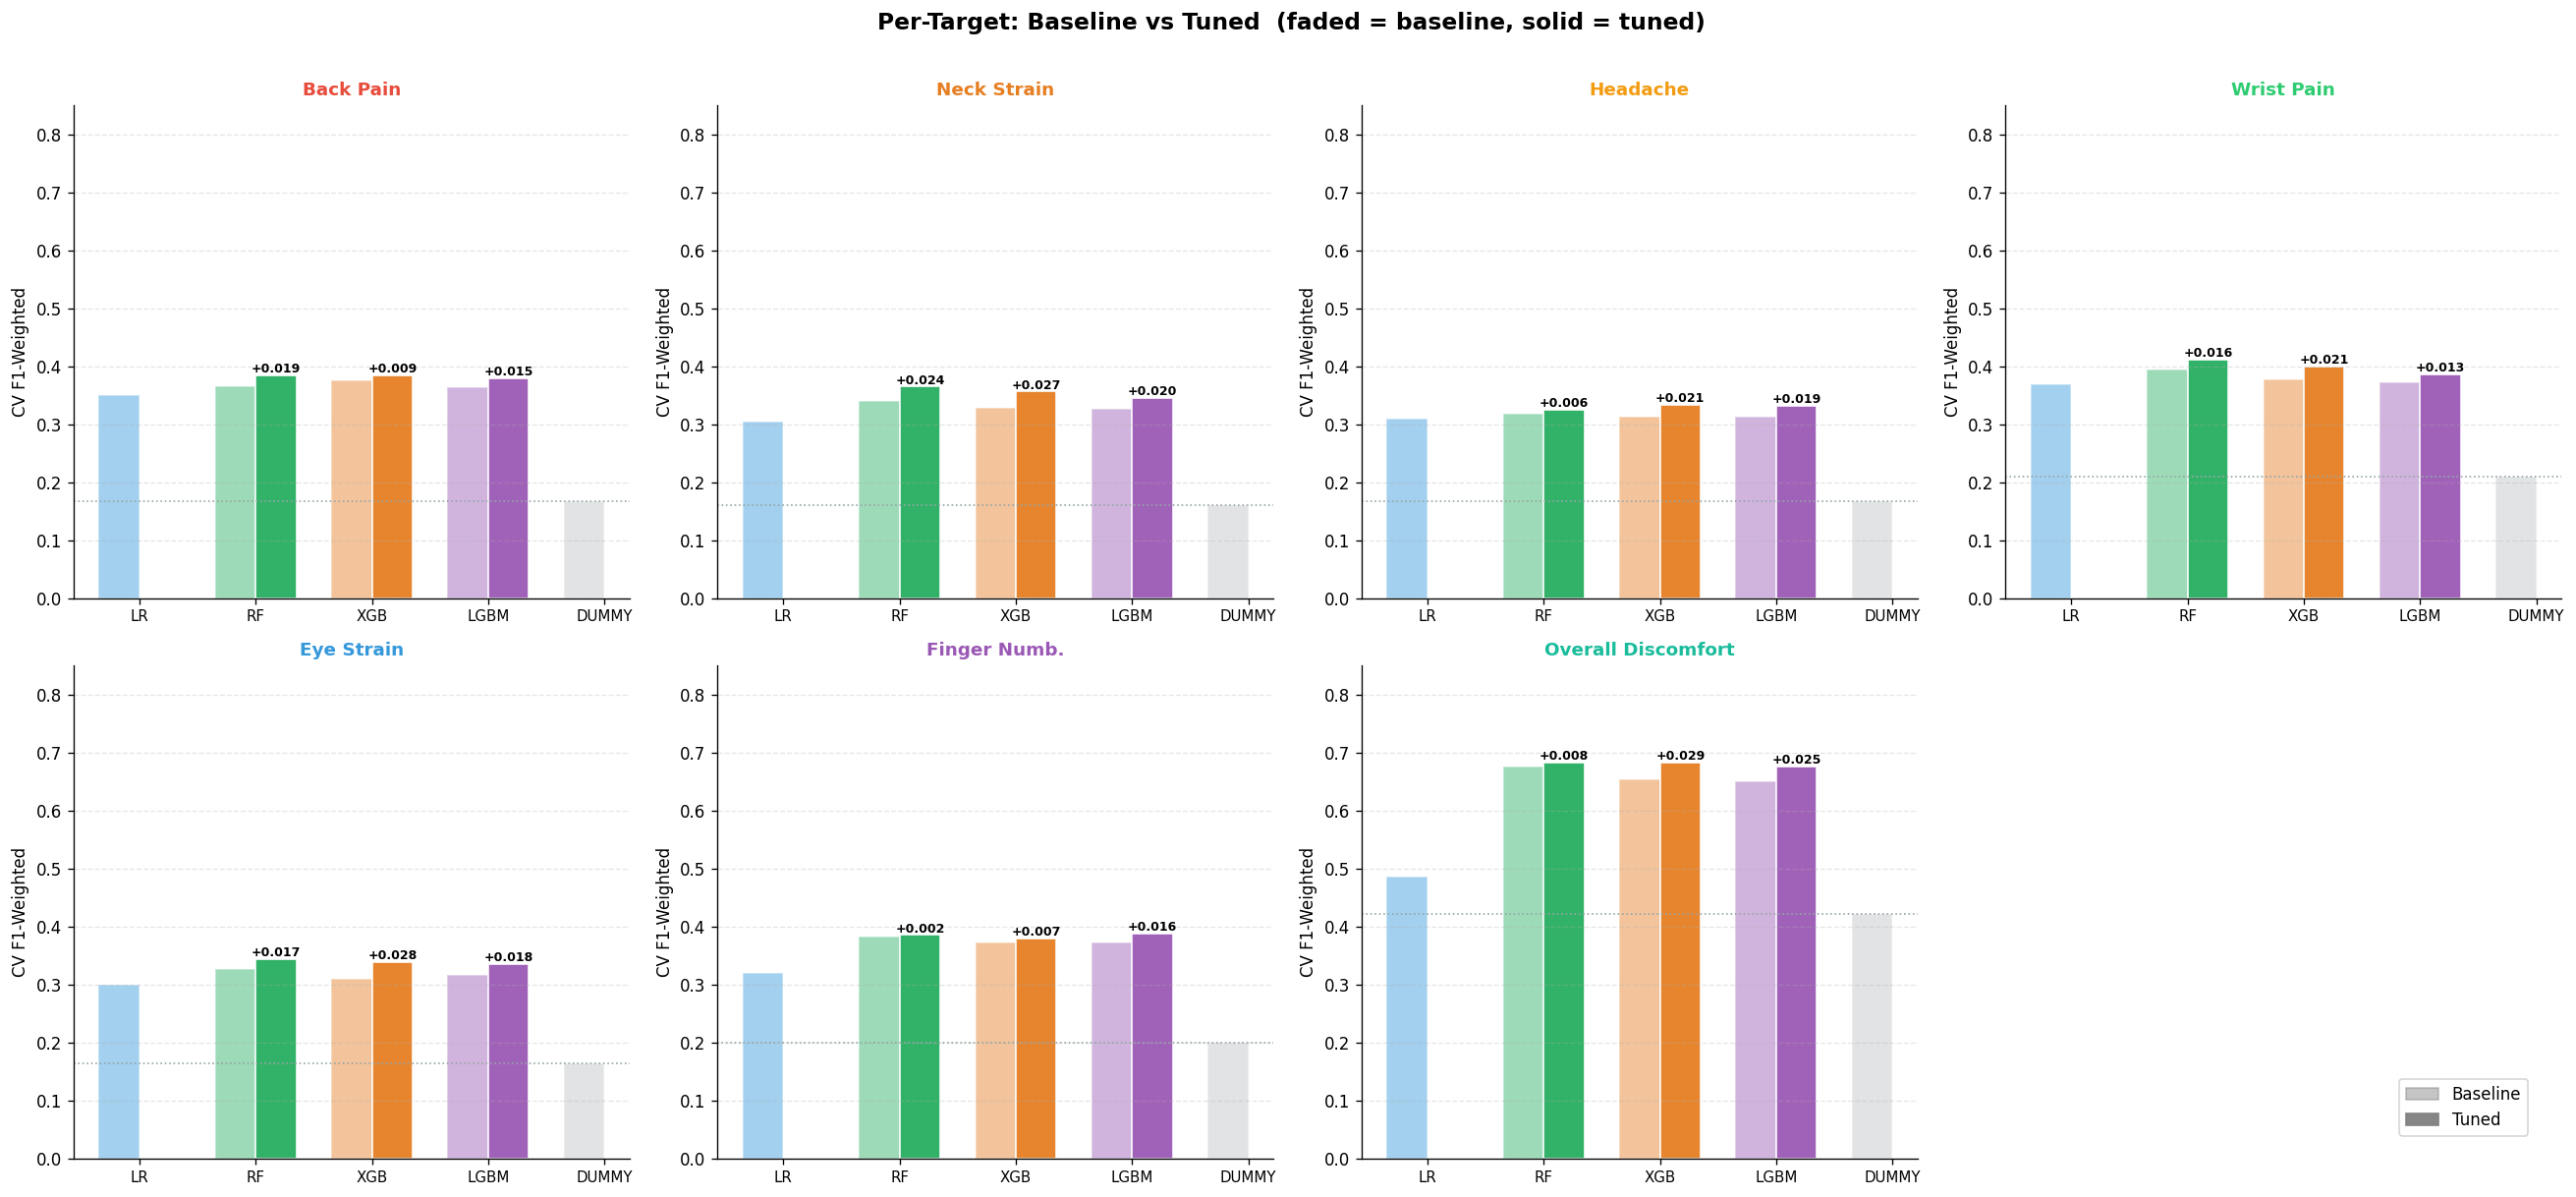

In [12]:
# ── All-models comparison per target — small multiples ───────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, t in enumerate(TARGET_COLS):
    ax = axes[i]
    models_in_t = list(tuning[t].keys())
    all_models  = MODEL_NAMES + ['DUMMY']

    base_vals  = [baseline[t][m]['f1_weighted'] for m in all_models]
    tuned_vals = [tuning[t].get(m, None)        for m in all_models]

    x  = np.arange(len(all_models))
    w  = 0.35
    bar_cols = [MODEL_COLORS[m] for m in all_models]

    axes[i].bar(x - w/2, base_vals, width=w, color=bar_cols,
                alpha=0.45, edgecolor='white', label='Baseline')
    # Only plot tuned where available
    for j, (m, tv) in enumerate(zip(all_models, tuned_vals)):
        if tv is not None:
            axes[i].bar(j + w/2, tv, width=w,
                        color=MODEL_COLORS[m], alpha=0.95,
                        edgecolor='white')
            gain = tv - base_vals[j]
            axes[i].text(j + w/2, tv + 0.005, f'+{gain:.3f}',
                         ha='center', fontsize=7.5, fontweight='bold')

    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_models, fontsize=9)
    axes[i].set_ylim(0, 0.85)
    axes[i].set_ylabel('CV F1-Weighted')
    axes[i].set_title(TARGET_NICE[t], fontweight='bold',
                       color=TARGET_COLORS[t], fontsize=11)
    axes[i].axhline(baseline[t]['DUMMY']['f1_weighted'],
                    color='#95a5a6', lw=1, linestyle=':')

axes[-1].axis('off')
pale  = mpatches.Patch(color='grey', alpha=0.45, label='Baseline')
solid = mpatches.Patch(color='grey', alpha=0.95, label='Tuned')
fig.legend(handles=[pale, solid], fontsize=10,
           loc='lower right', bbox_to_anchor=(0.98, 0.05))

plt.suptitle('Per-Target: Baseline vs Tuned  (faded = baseline, solid = tuned)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 6. Cross-Model Ranking Analysis

In [13]:
# ── Rank each model per target (1=best) based on tuned score ─────────────────
rank_data = {}
for t in TARGET_COLS:
    scores_t = {m: tuning[t].get(m, baseline[t][m]['f1_weighted'])
                for m in MODEL_NAMES}
    sorted_m = sorted(scores_t, key=scores_t.get, reverse=True)
    rank_data[TARGET_NICE[t]] = {m: sorted_m.index(m)+1 for m in MODEL_NAMES}

rank_df = pd.DataFrame(rank_data).T
print("=== MODEL RANKS PER TARGET (1 = best) ===")
print(rank_df.to_string())
print(f"\nMean rank across all targets:")
print(rank_df.mean().sort_values().round(3).to_string())


=== MODEL RANKS PER TARGET (1 = best) ===
                    LR  RF  XGB  LGBM
Back Pain            4   2    1     3
Neck Strain          4   1    2     3
Headache             4   3    1     2
Wrist Pain           4   1    2     3
Eye Strain           4   1    2     3
Finger Numb.         4   2    3     1
Overall Discomfort   4   1    2     3

Mean rank across all targets:
RF      1.571
XGB     1.857
LGBM    2.571
LR      4.000


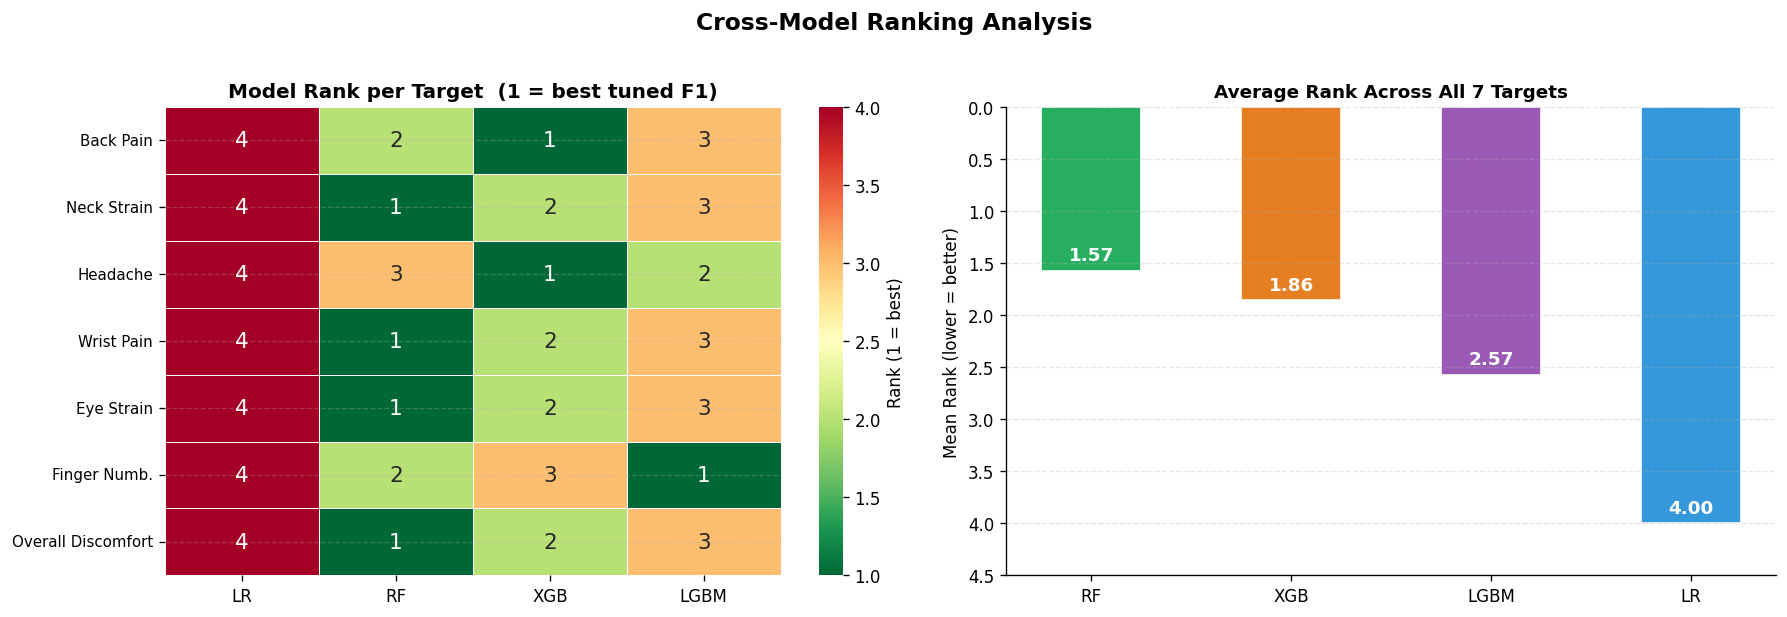

In [14]:
# ── Rank heatmap ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(rank_df, annot=True, fmt='.0f', cmap='RdYlGn_r',
            vmin=1, vmax=4, linewidths=0.5,
            ax=axes[0], annot_kws={'size': 13},
            cbar_kws={'label': 'Rank (1 = best)'})
axes[0].set_title('Model Rank per Target  (1 = best tuned F1)',
                   fontweight='bold', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=9)

# Mean rank bar
mean_ranks = rank_df.mean().sort_values()
bar_cols   = [MODEL_COLORS[m] for m in mean_ranks.index]
bars = axes[1].bar(mean_ranks.index, mean_ranks.values,
                   color=bar_cols, edgecolor='white', width=0.5)
axes[1].set_ylabel('Mean Rank (lower = better)')
axes[1].set_title('Average Rank Across All 7 Targets', fontweight='bold')
axes[1].set_ylim(0, 4.5)
axes[1].invert_yaxis()
for bar, v in zip(bars, mean_ranks.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, v-0.1,
                 f'{v:.2f}', ha='center', fontsize=11, fontweight='bold',
                 color='white')

plt.suptitle('Cross-Model Ranking Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


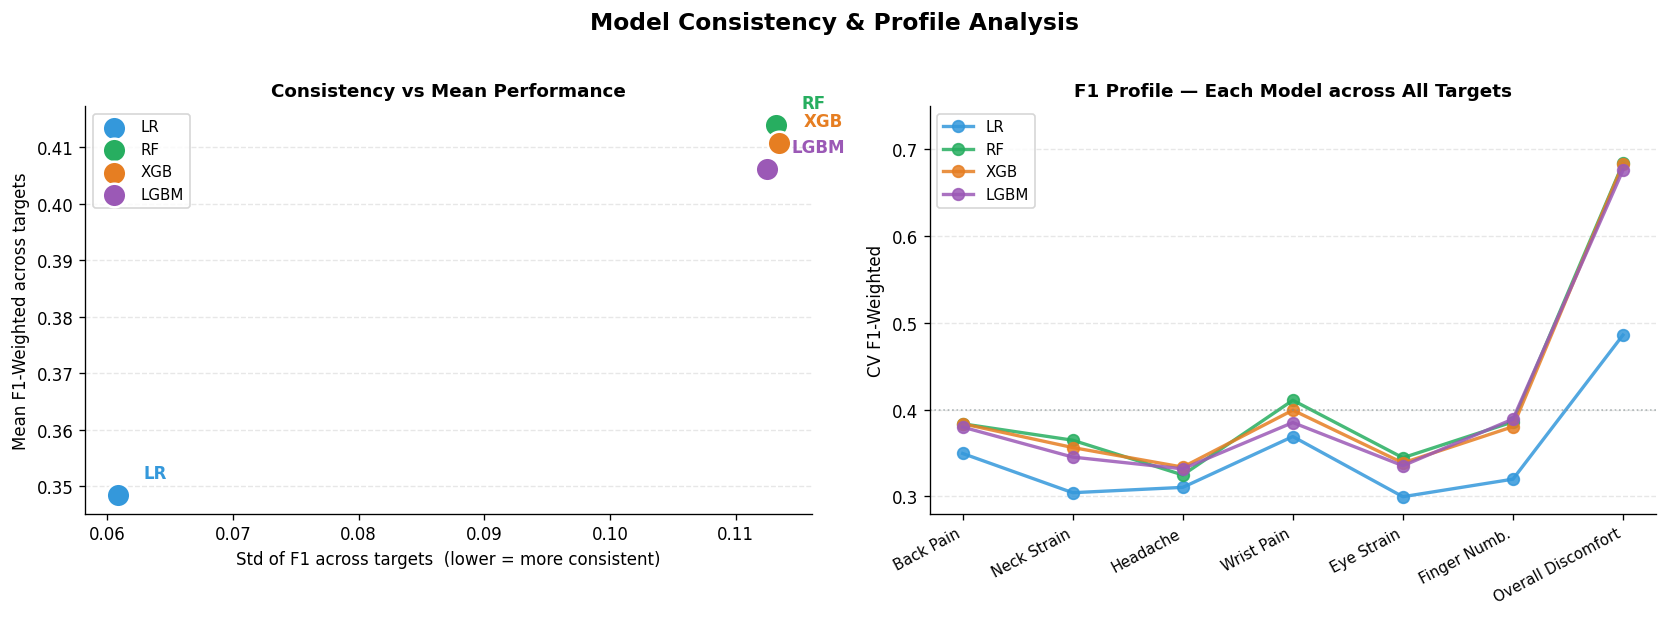

In [15]:
# ── Consistency: std of F1 across targets per model ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean F1 vs consistency (std across targets)
for m in MODEL_NAMES:
    f1s  = [tuning[t].get(m, baseline[t][m]['f1_weighted']) for t in TARGET_COLS]
    mean = np.mean(f1s)
    std  = np.std(f1s)
    axes[0].scatter(std, mean, color=MODEL_COLORS[m], s=200, zorder=5,
                    edgecolors='white', linewidths=1.5, label=m)
    axes[0].annotate(m, (std+0.002, mean+0.003), fontsize=10, fontweight='bold',
                     color=MODEL_COLORS[m])

axes[0].set_xlabel('Std of F1 across targets  (lower = more consistent)')
axes[0].set_ylabel('Mean F1-Weighted across targets')
axes[0].set_title('Consistency vs Mean Performance', fontweight='bold')
axes[0].legend(fontsize=9)

# F1 profile per model across targets
for m in MODEL_NAMES:
    f1s = [tuning[t].get(m, baseline[t][m]['f1_weighted']) for t in TARGET_COLS]
    axes[1].plot(range(len(TARGET_COLS)), f1s, marker='o', lw=2, ms=7,
                 color=MODEL_COLORS[m], label=m, alpha=0.85)

axes[1].set_xticks(range(len(TARGET_COLS)))
axes[1].set_xticklabels([TARGET_NICE[t] for t in TARGET_COLS],
                         rotation=28, ha='right', fontsize=9)
axes[1].set_ylabel('CV F1-Weighted')
axes[1].set_ylim(0.28, 0.75)
axes[1].set_title('F1 Profile — Each Model across All Targets', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].axhline(0.40, color='#7f8c8d', lw=1, linestyle=':', alpha=0.6)

plt.suptitle('Model Consistency & Profile Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 7. Final Summary Table & Export

In [16]:
# ── Master results table ──────────────────────────────────────────────────────
summary_rows = []
for t in TARGET_COLS:
    best_m      = best_tuned[t]
    best_f1     = tuning[t][best_m]
    base_f1     = baseline[t][best_m]['f1_weighted']
    dummy_f1    = baseline[t]['DUMMY']['f1_weighted']
    lift_vs_base  = best_f1 - base_f1
    lift_vs_dummy = best_f1 - dummy_f1

    # second best
    sorted_t = sorted(tuning[t].items(), key=lambda x: x[1], reverse=True)
    margin   = sorted_t[0][1] - sorted_t[1][1] if len(sorted_t) > 1 else 0

    summary_rows.append({
        'Target':           TARGET_NICE[t],
        'Best Model':       best_m,
        'Baseline F1_wt':   round(base_f1,        4),
        'Tuned F1_wt':      round(best_f1,        4),
        'Gain vs Baseline': round(lift_vs_base,   4),
        'Gain vs Dummy':    round(lift_vs_dummy,  4),
        'Margin over 2nd':  round(margin,         4),
        'Meets 0.75 Target': '✓' if best_f1 >= 0.75 else '✗',
    })

summary_df = pd.DataFrame(summary_rows)
print("=== PHASE 4 FINAL RESULTS SUMMARY ===")
print(summary_df.to_string(index=False))
print()
print(f"Models meeting F1 ≥ 0.75: "
      f"{(summary_df['Meets 0.75 Target']=='✓').sum()} / {len(summary_df)}")
print(f"Mean tuned F1-weighted : {summary_df['Tuned F1_wt'].mean():.4f}")
print(f"Best target            : {summary_df.loc[summary_df['Tuned F1_wt'].idxmax(), 'Target']} "
      f"({summary_df['Tuned F1_wt'].max():.4f})")
print(f"Hardest target         : {summary_df.loc[summary_df['Tuned F1_wt'].idxmin(), 'Target']} "
      f"({summary_df['Tuned F1_wt'].min():.4f})")


=== PHASE 4 FINAL RESULTS SUMMARY ===
            Target Best Model  Baseline F1_wt  Tuned F1_wt  Gain vs Baseline  Gain vs Dummy  Margin over 2nd Meets 0.75 Target
         Back Pain        XGB          0.3752       0.3838            0.0086         0.2171           0.0001                 ✗
       Neck Strain         RF          0.3403       0.3648            0.0245         0.2041           0.0085                 ✗
          Headache        XGB          0.3123       0.3338            0.0215         0.1671           0.0020                 ✗
        Wrist Pain         RF          0.3949       0.4109            0.0160         0.2013           0.0114                 ✗
        Eye Strain         RF          0.3276       0.3446            0.0169         0.1801           0.0060                 ✗
      Finger Numb.       LGBM          0.3735       0.3891            0.0156         0.1884           0.0032                 ✗
Overall Discomfort         RF          0.6761       0.6838            0.0

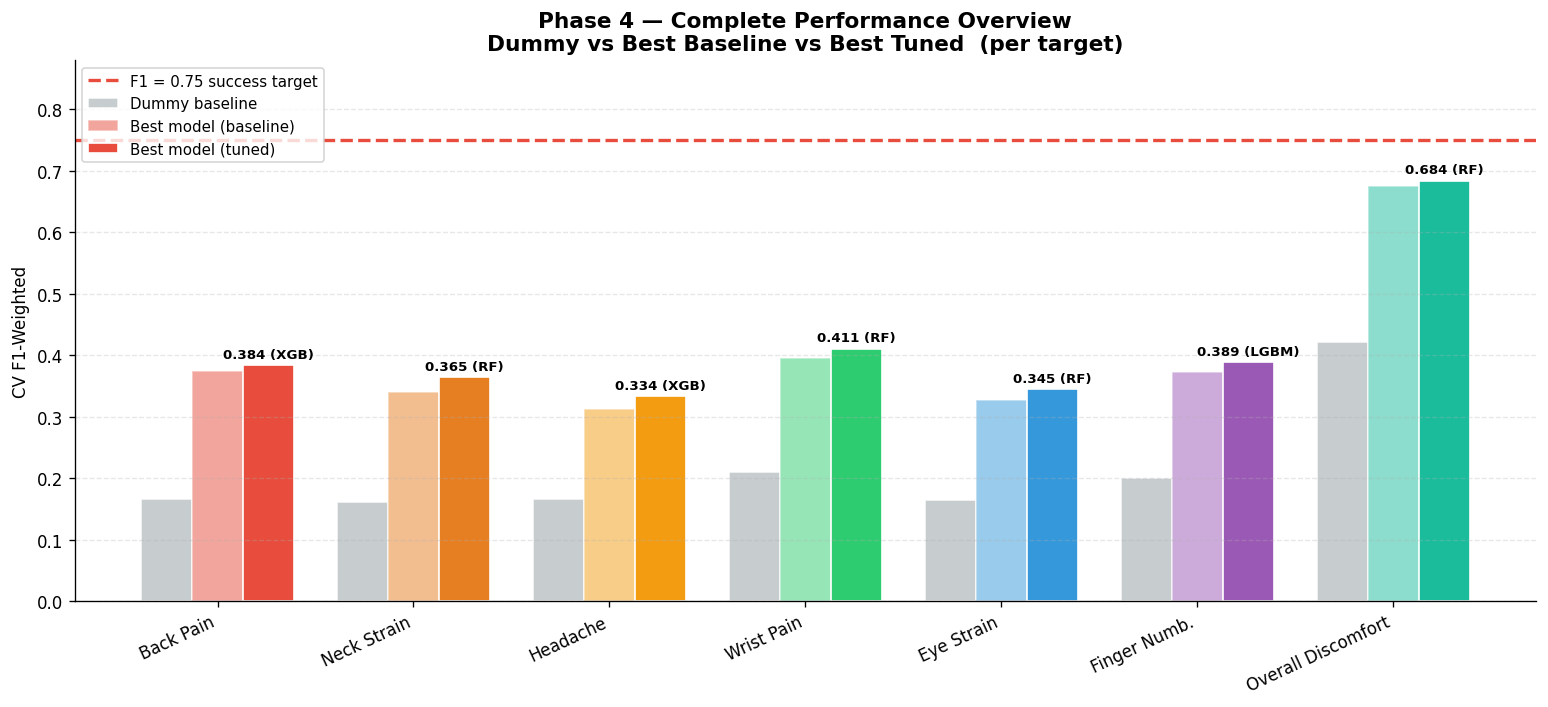

In [17]:
# ── Final performance overview chart ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

targets_nice = [TARGET_NICE[t] for t in TARGET_COLS]
base_f1s = [baseline[t][best_tuned[t]]['f1_weighted'] for t in TARGET_COLS]
tuned_f1s = [tuning[t][best_tuned[t]]                 for t in TARGET_COLS]
dummy_f1s = [baseline[t]['DUMMY']['f1_weighted']       for t in TARGET_COLS]
bar_cols  = [TARGET_COLORS[t]                          for t in TARGET_COLS]

x = np.arange(len(TARGET_COLS))
w = 0.26

ax.bar(x - w, dummy_f1s,  width=w, color='#bdc3c7', edgecolor='white',
       label='Dummy baseline', alpha=0.85)
ax.bar(x,     base_f1s,   width=w, color=bar_cols,  edgecolor='white',
       label='Best model (baseline)', alpha=0.50)
ax.bar(x + w, tuned_f1s,  width=w, color=bar_cols,  edgecolor='white',
       label='Best model (tuned)', alpha=1.0)

ax.axhline(0.75, color='#e74c3c', lw=2, linestyle='--',
           label='F1 = 0.75 success target')

ax.set_xticks(x)
ax.set_xticklabels(targets_nice, rotation=25, ha='right', fontsize=10)
ax.set_ylabel('CV F1-Weighted')
ax.set_ylim(0, 0.88)
ax.set_title('Phase 4 — Complete Performance Overview\n'
             'Dummy vs Best Baseline vs Best Tuned  (per target)',
             fontweight='bold', fontsize=13)

for i, (t, tv, bm) in enumerate(zip(TARGET_COLS, tuned_f1s, [best_tuned[t] for t in TARGET_COLS])):
    ax.text(i + w, tv + 0.012, "{:.3f} ({})".format(tv, bm),
            ha='center', fontsize=8, fontweight='bold')

ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()


In [18]:
# ── Save summary CSV ──────────────────────────────────────────────────────────
summary_df.to_csv('phase4_model_summary.csv', index=False)
print("✓ Saved phase4_model_summary.csv")

print(f"\n{'='*65}")
print(f"  PHASE 4 ANALYSIS COMPLETE")
print(f"{'='*65}")
print(f"  {'Target':22s}  {'Best Model':10s}  {'Tuned F1_wt':12s}  {'Gain':6s}  {'≥0.75?':6s}")
print(f"  {'-'*62}")
for _, row in summary_df.iterrows():
    print(f"  {row['Target']:22s}  {row['Best Model']:10s}  "
          f"{row['Tuned F1_wt']:.4f}        "
          f"+{row['Gain vs Baseline']:.4f}  {row['Meets 0.75 Target']}")
print(f"{'='*65}")


✓ Saved phase4_model_summary.csv

  PHASE 4 ANALYSIS COMPLETE
  Target                  Best Model  Tuned F1_wt   Gain    ≥0.75?
  --------------------------------------------------------------
  Back Pain               XGB         0.3838        +0.0086  ✗
  Neck Strain             RF          0.3648        +0.0245  ✗
  Headache                XGB         0.3338        +0.0215  ✗
  Wrist Pain              RF          0.4109        +0.0160  ✗
  Eye Strain              RF          0.3446        +0.0169  ✗
  Finger Numb.            LGBM        0.3891        +0.0156  ✗
  Overall Discomfort      RF          0.6838        +0.0076  ✗
